In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
time_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/time.csv')
print(time_df.shape)
print(time_df.head(5))
#It has 8,640 rows. Each row is one 5-minute slot from June 19 to July 18.
# 8640 = 30 days × 24 hours × 12 (five-minute intervals per hour) = 8640 ✓

(8640, 6)
   month  day  year  hour  minute  second
0      6   19  2022     0       0       0
1      6   19  2022     0       5       0
2      6   19  2022     0      10       0
3      6   19  2022     0      15       0
4      6   19  2022     0      20       0


In [3]:
occ_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/occupancy.csv')
print(occ_df.shape)
print(occ_df.head(5))
#102,105,107 wagera sab station ids hai
# Each cell value: how many chargers at that station are occupied right now

(8640, 248)
   timestamp  102  105  107  108  109  110  111  115  123  ...  1160  1162  \
0          1   12   16   24   15    6    8   24    1    2  ...     0    12   
1          2   12   16   24   15    6    8   24    1    2  ...     0    12   
2          3   12   16   24   15    6    8   24    1    2  ...     0    12   
3          4   12   16   24   15    6    8   24    1    2  ...     0    12   
4          5   12   16   24   15    6    8   24    1    2  ...     0    12   

   1163  1164  1166  1167  1168  1170  1172  1173  
0     1    38    26   162    10     1     8    15  
1     1    38    26   162    10     1     8    15  
2     1    38    26   164    10     1     8    15  
3     1    38    26   166    10     1     8    15  
4     1    38    26   168    10     1     8    15  

[5 rows x 248 columns]


In [4]:
vol_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/volume.csv')
print(vol_df.shape)
print(vol_df.head(5))
# same structure — kWh consumed

(8640, 248)
   timestamp       102       105       107    108       109       110  \
0          1  2.858333  5.907222  6.478889  5.145  2.286667  3.048889   
1          2  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
2          3  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
3          4  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
4          5  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   

        111       115       123  ...  1160      1162      1163       1164  \
0  5.526111  0.381111  0.762222  ...   0.0  2.286667  0.381111  12.195556   
1  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
2  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
3  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
4  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   

        1166        1167      1168      1170      1172      1173  
0   8.956111  240.2

In [5]:
price_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/price.csv')
print(price_df.shape)
print(price_df.head(5))

(8640, 248)
   timestamp    102       105       107   108    109    110       111   115  \
0          1  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   
1          2  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   
2          3  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   
3          4  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   
4          5  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   

        123  ...  1160   1162  1163      1164  1166      1167      1168  1170  \
0  0.543333  ...  0.69  0.905   0.7  0.956875  1.04  0.753185  0.906667   1.2   
1  0.543333  ...  0.69  0.905   0.7  0.956875  1.04  0.753185  0.906667   1.2   
2  0.543333  ...  0.69  0.905   0.7  0.956875  1.04  0.753185  0.906667   1.2   
3  0.543333  ...  0.69  0.905   0.7  0.956875  1.04  0.753185  0.906667   1.2   
4  0.543333  ...  0.69  0.905   0.7  0.956875  1.04  0.753185  0.906667   1.2   

    1172    1173  
0  1.03

In [6]:
dur_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/duration.csv')
print(dur_df.shape)
print(dur_df.head(5))
################################################ session duration wali baat samajh nahi aayi
# same structure — session duration

# Yeh file batati hai ki us specific 5-minute ke window mein, us station par total kitni der ki charging hui (sab gaadiyon ko milakar).
# Iska math samajhiye:
# Agar 1 gaadi pure 5 minute tak charge hoti hai, toh wo system mein 0.0833 hours (5/60) ka duration add karti hai.
# Agar kisi row mein Station '102' ke aage 0.75 likha hai, toh 0.75 hours ka matlab hota hai 45 minutes.
# Ab 45 minutes ko 5 se divide kariye (45/5 = 9). Iska matlab us 5 minute ke interval mein exact 9 gaadiyan ek saath charge ho rahi thi!

# Isko cross-verify karte hain baaki files ke saath:
# Aapke paas jo dusri files hain, unse yeh poori tarah prove ho jata hai:
# information.csv: Station '102' par total 30 chargers (piles) hain.
# occupancy.csv: Same time par Station '102' ki occupancy 12 hai. Yaani 30 mein se 12 chargers par gaadiyan khadi hain.
# duration.csv: Duration 0.75 (yaani 9 gaadiyon ke barabar) hai.
# Result: Iska matlab 12 gaadiyan wahan park hain, jisme se 9 gaadiyan actively charge ho rahi hain, 
# aur 3 gaadiyan aisi hain jo ya toh fully charge ho chuki hain par abhi bhi plug-in hain, ya fir unki charging shuru nahi hui hai.

(8640, 248)
   timestamp   102       105   107       108       109       110   111  \
0          1  0.49  0.871111  0.98  0.762222  0.326667  0.381111  0.98   
1          2  0.75  1.333333  1.50  1.166667  0.500000  0.583333  1.50   
2          3  0.75  1.333333  1.50  1.166667  0.500000  0.583333  1.50   
3          4  0.75  1.333333  1.50  1.166667  0.500000  0.583333  1.50   
4          5  0.75  1.333333  1.50  1.166667  0.500000  0.583333  1.50   

        115       123  ...  1160      1162      1163      1164      1166  \
0  0.054444  0.108889  ...   0.0  0.326667  0.054444  1.905556  1.306667   
1  0.083333  0.166667  ...   0.0  0.500000  0.083333  2.916667  2.000000   
2  0.083333  0.166667  ...   0.0  0.500000  0.083333  2.916667  2.000000   
3  0.083333  0.166667  ...   0.0  0.500000  0.083333  2.916667  2.000000   
4  0.083333  0.166667  ...   0.0  0.500000  0.083333  2.916667  2.000000   

        1167      1168      1170      1172      1173  
0   8.493333  0.544444  0.05444

In [7]:
info_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/information.csv')
print(info_df.shape)
print(info_df.head(5))

(247, 10)
   num  grid  count  fast_count  slow_count  area       lon        la  CBD  \
0    1   102     30           3          27  0.71  114.1030  22.54041    0   
1    3   105     93           0          93  0.77  114.1208  22.55127    0   
2    5   107     88           2          86  0.89  114.1304  22.54486    0   
3    6   108     39           0          39  1.26  114.1315  22.55403    0   
4    7   109     39           0          39  3.15  114.1430  22.56388    0   

   dynamic_pricing  
0                0  
1                0  
2                0  
3                0  
4                0  


In [8]:
stations_df = pd.read_csv('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/UrbanEV_ SZ_districts/stations.csv')
print(stations_df.shape)
print(stations_df.head(5))

(1706, 6)
   station_id   latitude   longitude  fast  slow  count
0           1  22.716272  113.826349     5     5     10
1           2  22.678851  114.049721    20     0     20
2           3  22.509541  114.058510     0     8      8
3           4  22.605970  114.122110     0     6      6
4           5  22.732771  113.816951     0    55     55


In [9]:
time_df['datetime'] = pd.to_datetime(
    time_df[['year', 'month', 'day', 'hour', 'minute', 'second']]
)

print(f"Date range: {time_df['datetime'].min()}  →  {time_df['datetime'].max()}")
print(f"Total time span: 30 days, sampled every 5 minutes")

Date range: 2022-06-19 00:00:00  →  2022-07-18 23:55:00
Total time span: 30 days, sampled every 5 minutes


In [10]:
print(time_df.head())
print(time_df['datetime'].head())

   month  day  year  hour  minute  second            datetime
0      6   19  2022     0       0       0 2022-06-19 00:00:00
1      6   19  2022     0       5       0 2022-06-19 00:05:00
2      6   19  2022     0      10       0 2022-06-19 00:10:00
3      6   19  2022     0      15       0 2022-06-19 00:15:00
4      6   19  2022     0      20       0 2022-06-19 00:20:00
0   2022-06-19 00:00:00
1   2022-06-19 00:05:00
2   2022-06-19 00:10:00
3   2022-06-19 00:15:00
4   2022-06-19 00:20:00
Name: datetime, dtype: datetime64[ns]


In [11]:
for df in [occ_df, vol_df, price_df, dur_df]:
    df['datetime'] = time_df['datetime'].values

print("✓ Datetime added to all tables")

✓ Datetime added to all tables


In [12]:
print("Melting occupancy... (this makes 2.1 million rows — that's correct!)")
occ_long = occ_df.melt(
    id_vars=['timestamp', 'datetime'],#keep them unchanged 
    var_name='station_id', # Bache hue columns hi heading
    value_name='occupancy'  #Bache hue columns ke Andar ka Data
)

print("Melting volume...")
vol_long = vol_df.melt(
    id_vars=['timestamp', 'datetime'],
    var_name='station_id',
    value_name='volume_kwh'
)

print("Melting price...")
price_long = price_df.melt(
    id_vars=['timestamp', 'datetime'],
    var_name='station_id',
    value_name='price_per_kwh'
)

print("Melting duration...")
dur_long = dur_df.melt(
    id_vars=['timestamp', 'datetime'],
    var_name='station_id',
    value_name='duration_hours'
)

print(f"\n✓ All tables melted. Long occupancy shape: {occ_long.shape}")


Melting occupancy... (this makes 2.1 million rows — that's correct!)
Melting volume...
Melting price...
Melting duration...

✓ All tables melted. Long occupancy shape: (2134080, 4)


In [13]:
occ_long.head(5)

,timestamp,datetime,station_id,occupancy
0,1,2022-06-19 00:00:00,102,12
1,2,2022-06-19 00:05:00,102,12
2,3,2022-06-19 00:10:00,102,12
3,4,2022-06-19 00:15:00,102,12
4,5,2022-06-19 00:20:00,102,12


In [14]:
vol_long.head()

,timestamp,datetime,station_id,volume_kwh
0,1,2022-06-19 00:00:00,102,2.858333
1,2,2022-06-19 00:05:00,102,4.375000
2,3,2022-06-19 00:10:00,102,4.375000
3,4,2022-06-19 00:15:00,102,4.375000
4,5,2022-06-19 00:20:00,102,4.375000


In [15]:
price_long.head()

,timestamp,datetime,station_id,price_per_kwh
0,1,2022-06-19 00:00:00,102,0.924
1,2,2022-06-19 00:05:00,102,0.924
2,3,2022-06-19 00:10:00,102,0.924
3,4,2022-06-19 00:15:00,102,0.924
4,5,2022-06-19 00:20:00,102,0.924


In [16]:
dur_long.head()

,timestamp,datetime,station_id,duration_hours
0,1,2022-06-19 00:00:00,102,0.49
1,2,2022-06-19 00:05:00,102,0.75
2,3,2022-06-19 00:10:00,102,0.75
3,4,2022-06-19 00:15:00,102,0.75
4,5,2022-06-19 00:20:00,102,0.75


In [17]:
#Like vlookup
master = occ_long.copy()
master = master.merge(vol_long[['timestamp','station_id','volume_kwh']],
                      on=['timestamp','station_id'])
master = master.merge(price_long[['timestamp','station_id','price_per_kwh']],
                      on=['timestamp','station_id'])
master = master.merge(dur_long[['timestamp','station_id','duration_hours']],
                      on=['timestamp','station_id'])

print(f"Master table shape: {master.shape}")
print(master.head().to_string(index=False))


Master table shape: (2134080, 7)
 timestamp            datetime station_id  occupancy  volume_kwh  price_per_kwh  duration_hours
         1 2022-06-19 00:00:00        102         12    2.858333          0.924            0.49
         2 2022-06-19 00:05:00        102         12    4.375000          0.924            0.75
         3 2022-06-19 00:10:00        102         12    4.375000          0.924            0.75
         4 2022-06-19 00:15:00        102         12    4.375000          0.924            0.75
         5 2022-06-19 00:20:00        102         12    4.375000          0.924            0.75


In [18]:
master['hour']       = master['datetime'].dt.hour
master['day_of_week'] = master['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
master['is_weekend'] = (master['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun
#convert to proper date time

In [19]:
def time_period(h):
    if 7 <= h < 12:  return 'Morning Peak'
    elif 12 <= h < 14: return 'Lunch'
    elif 14 <= h < 19: return 'Afternoon'
    elif 19 <= h < 23: return 'Evening'
    else:              return 'Night / Off-peak'

master['time_period'] = master['hour'].apply(time_period)

print("✓ Time features added: hour, day_of_week, is_weekend, time_period")

✓ Time features added: hour, day_of_week, is_weekend, time_period


In [20]:
print(master['time_period'].value_counts())

time_period
Night / Off-peak    711360
Morning Peak        444600
Afternoon           444600
Evening             355680
Lunch               177840
Name: count, dtype: int64


In [21]:
# Correct rename: grid = station ID, not num
info_df = info_df.rename(columns={'grid': 'station_id'})

master['station_id'] = master['station_id'].astype(int)

master = master.merge(
    info_df[['station_id', 'count', 'fast_count', 'slow_count',
             'CBD', 'area', 'dynamic_pricing']],   # add dynamic_pricing!
    on='station_id',
    how='left'
)

master['utilization_rate'] = (master['occupancy'] / master['count']).clip(0, 1)#.clip(0,1) ensures ke 0 to 1 ke beech mein aaye
master['revenue'] = master['volume_kwh'] * master['price_per_kwh']

# New: flag whether this station already uses dynamic pricing
# This lets us compare dynamic vs flat-rate stations in EDA
print("Stations with dynamic pricing:", master['dynamic_pricing'].sum() / master['dynamic_pricing'].count())
print("Unique dynamic pricing stations:", master[master['dynamic_pricing']==1]['station_id'].nunique())
#iss code se A B testing hoyegi ke with dynamic wale good ya without wale

Stations with dynamic pricing: 0.23076923076923078
Unique dynamic pricing stations: 57


# EDA Begins

In [23]:
hourly = master.groupby('hour').agg(
    avg_occupancy    = ('occupancy',         'mean'),
    avg_utilization  = ('utilization_rate',  'mean'),
    
    # median tells you the "typical" station at this hour
    median_util      = ('utilization_rate',  'median'),
    
    # 90th percentile tells you: at peak hour, the top 10% of stations
    # are AT or ABOVE this utilization — this is your congestion signal
    p90_util         = ('utilization_rate',  lambda x: x.quantile(0.90)),
    p95_util         = ('utilization_rate',  lambda x: x.quantile(0.95)),
    
    avg_revenue      = ('revenue',           'mean')
).round(3)

# #If you used median instead, you'd get the revenue of the middle-ranked station 
# — but that tells you nothing about how much money the whole network made.
# The total matters for a business.

# Yeh line poori table ko bina kate (without truncation) print karegi
print(hourly.to_string())

      avg_occupancy  avg_utilization  median_util  p90_util  p95_util  avg_revenue
hour                                                                              
0            26.198            0.332        0.305     0.615     0.700       35.383
1            26.427            0.334        0.308     0.620     0.698       36.799
2            26.022            0.328        0.302     0.600     0.677       33.075
3            25.871            0.326        0.300     0.595     0.676       31.835
4            25.819            0.325        0.300     0.595     0.676       32.157
5            25.945            0.327        0.300     0.600     0.679       33.664
6            26.094            0.331        0.301     0.622     0.711       37.383
7            23.775            0.303        0.275     0.573     0.667       35.932
8            20.305            0.261        0.241     0.475     0.556       28.883
9            19.230            0.250        0.223     0.465     0.543       23.069
10  

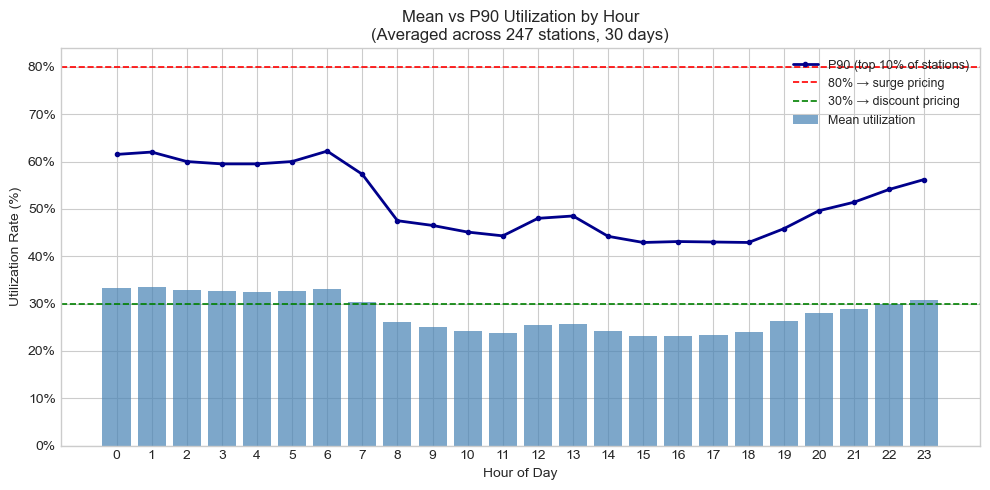

In [24]:
# ============================================================
# CHART 1: Mean vs P90 Utilization by Hour
# Shows WHEN stations are busiest + where surge/discount zones are
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(hourly.index, hourly['avg_utilization'] * 100,
       color='steelblue', alpha=0.7, label='Mean utilization')

ax.plot(hourly.index, hourly['p90_util'] * 100,
        color='darkblue', linewidth=2, marker='o', markersize=3,
        label='P90 (top 10% of stations)')

ax.axhline(80, color='red',   linestyle='--', linewidth=1.2, label='80% → surge pricing')
ax.axhline(30, color='green', linestyle='--', linewidth=1.2, label='30% → discount pricing')



ax.set_xlabel('Hour of Day')
ax.set_ylabel('Utilization Rate (%)')
ax.set_title('Mean vs P90 Utilization by Hour\n(Averaged across 247 stations, 30 days)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9,loc='upper right')

plt.tight_layout()
plt.savefig('chart1_utilization_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

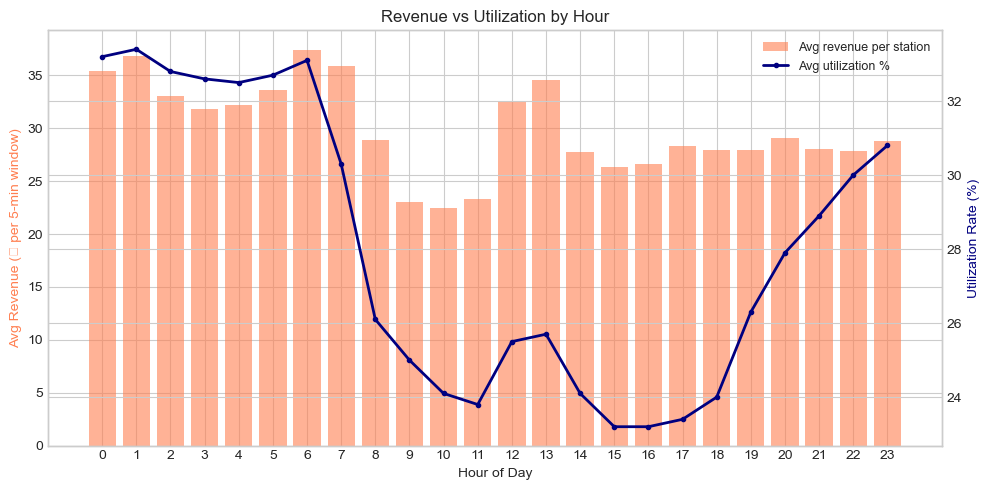

In [25]:
# ============================================================
# CHART 2: Revenue vs Utilization by Hour (twin y-axis)
# Shows that revenue and utilization DON'T perfectly align
# That gap = pricing inefficiency = what Agent 2 fixes
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax_twin = ax.twinx()
# Two y-axes on the same chart because revenue (₹) and
# utilization (%) have different units and scales

ax.bar(hourly.index, hourly['avg_revenue'],
       color='coral', alpha=0.6, label='Avg revenue per station')#label only taaki legend ch likh liye

ax_twin.plot(hourly.index, hourly['avg_utilization'] * 100,
             color='navy', linewidth=2, marker='o', markersize=3,
             label='Avg utilization %')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Revenue (₹ per 5-min window)', color='coral')
ax_twin.set_ylabel('Utilization Rate (%)', color='navy')
ax.set_title('Revenue vs Utilization by Hour')
ax.set_xticks(range(0, 24))

# Combine both legends into one
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig('chart2_revenue_vs_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

#12,13 matlab station te jyada gaddiyaan nahi hai par jo aayi ohna ne bohot bijli kharchi
# AI yahan kya karega: AI dekhega ki station toh khali pada hai.
# Wo yahan "Discount" de dega. Jab discount milega, toh bheed badhegi (line upar aayegi),
# aur aapke orange bars yahan aur bhi unche ho jayenge!

# Graph ajeeb kyu dikh raha hai? (Asli Problem yahan hai):
# Raat ka waqt (Jab Line upar hai, par Bars neeche hain):
# Sochiye ek insaan raat ko 10 baje apni EV charge pe lagakar so gaya. Gaadi 2 ghante mein (12 baje tak) 100% full ho gayi.
# Ab 12 baje se subah 6 baje tak gaadi koi bijli nahi kha rahi (Revenue = 0), lekin usne charger ko gher kar rakha hua hai (Utilization = 100%).
# Isko "Idle Time" ya "Charger Hogging" kehte hain. Yahi wajah hai ki bheed (line) badh rahi hai, par kamayi (bars) ruki hui hai!
# Dopahar ka waqt (Jab Bars upar hain, par Line neeche hai):
# Din mein log office/market ke time aate hain, 15-20 minute ke liye 'Fast Charger' par gaadi lagate hain, aur nikal jate hain.
# Yahan jagah zyada der nahi ghiri (Utilization kam hai), lekin 20 minute mein hi unhone bohot saari bijli khareed li (Revenue high hai).

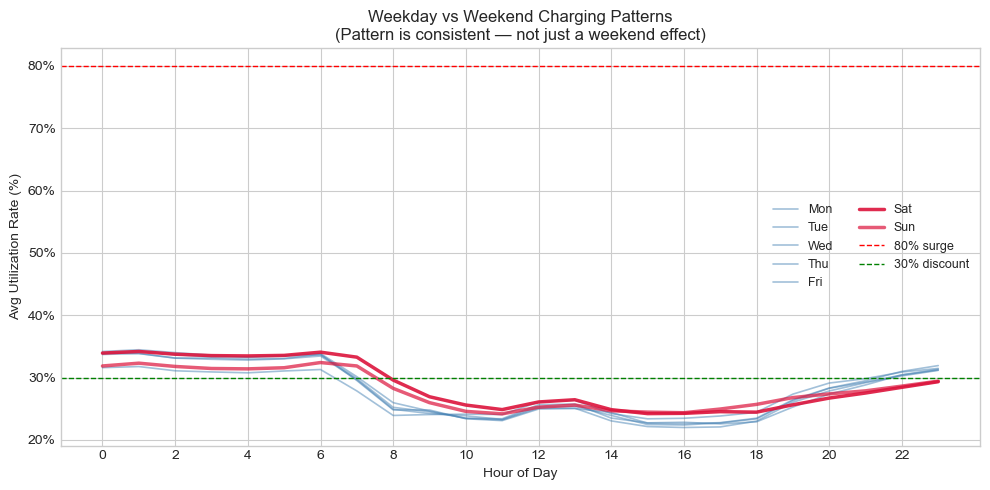

In [26]:
# ============================================================
# CHART 3: All 7 days overlaid as lines
# Weekend lines = thick red, Weekday lines = thin blue
# ============================================================

weekly_pivot = master.groupby(['day_of_week', 'hour'])['utilization_rate'].mean().unstack()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 5))

for i, day in enumerate(days):
    if i >= 5:  # Saturday, Sunday
        ax.plot(range(24), weekly_pivot.loc[i] * 100,
                label=day, linewidth=2.5, color='crimson',
                alpha=0.9 - (i - 5) * 0.2)# just changing transparency 
    else:
        ax.plot(range(24), weekly_pivot.loc[i] * 100,
                label=day, linewidth=1.2, color='steelblue', alpha=0.5)

ax.axhline(80, color='red',   linestyle='--', linewidth=1, label='80% surge')
ax.axhline(30, color='green', linestyle='--', linewidth=1, label='30% discount')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Utilization Rate (%)')
ax.set_title('Weekday vs Weekend Charging Patterns\n(Pattern is consistent — not just a weekend effect)')
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('chart3_weekday_weekend_lines.png', dpi=150, bbox_inches='tight')
plt.show()

#to prove ke sirf weekends pe high nahi hai raat ko usage

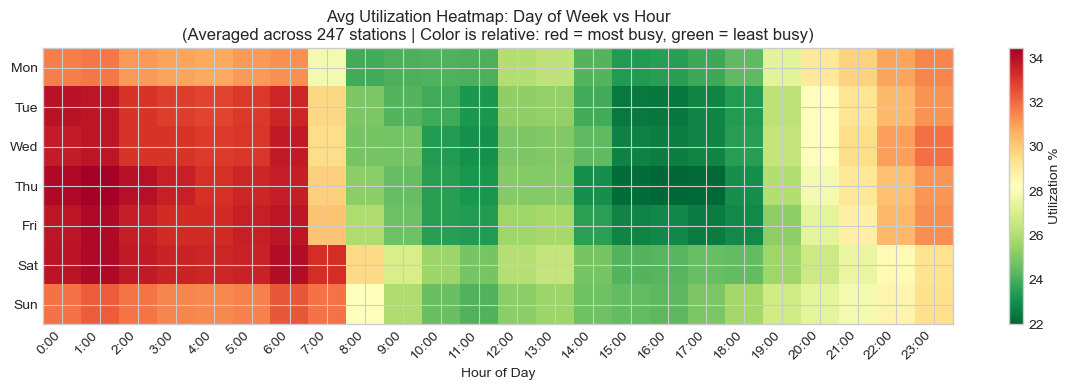

In [27]:
# ============================================================
# CHART 4: Heatmap — day of week vs hour of day
# Best chart for your presentation — tells the whole story visually
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4))

im = ax.imshow(weekly_pivot.values * 100,
               aspect='auto',
               cmap='RdYlGn_r')   # Red=high util, Green=low util (_r = reversed)

ax.set_yticks(range(7))
ax.set_yticklabels(days)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24)], rotation=45, ha='right')
ax.set_xlabel('Hour of Day')
ax.set_title('Avg Utilization Heatmap: Day of Week vs Hour\n'
             '(Averaged across 247 stations | Color is relative: red = most busy, green = least busy)')
plt.colorbar(im, ax=ax, label='Utilization %')

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

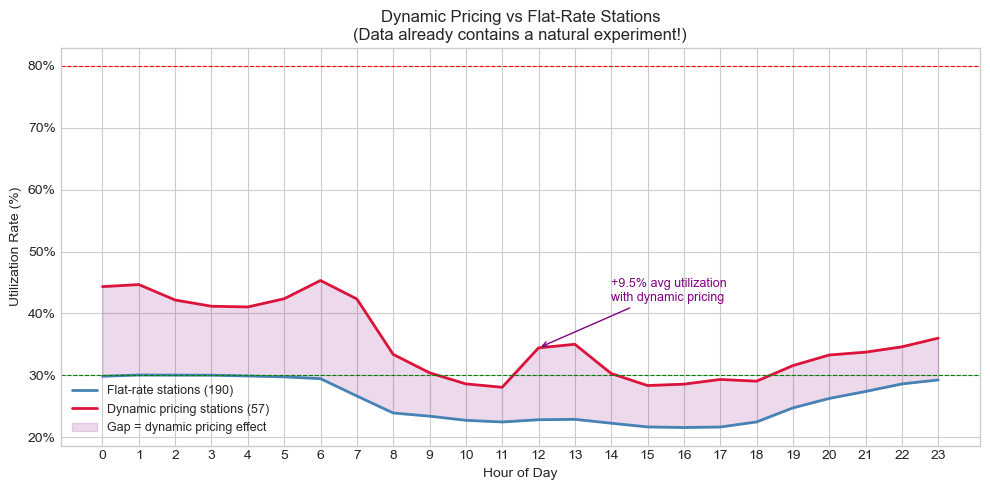

In [28]:
# ============================================================
# CHART 5: Dynamic pricing stations vs flat-rate stations
# This is the most powerful business insight in the whole dataset
# 57 stations already have dynamic pricing — we compare them to the other 190
# ============================================================

dyn_hourly = master.groupby(['dynamic_pricing', 'hour'])['utilization_rate'].mean().unstack()#unstack works in the backend
# Matlab: Data ko 2 groups mein baanto: 0 (Flat-rate) aur 1 (Dynamic Pricing). 
# Phir har group ka 24 ghante ka average utilization nikal lo aur use table form (unstack) mein saja do.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(24), dyn_hourly.loc[0] * 100,
        color='steelblue', linewidth=2, label='Flat-rate stations (190)')

ax.plot(range(24), dyn_hourly.loc[1] * 100,
        color='crimson', linewidth=2, label='Dynamic pricing stations (57)')

ax.fill_between(range(24),
                dyn_hourly.loc[0] * 100,
                dyn_hourly.loc[1] * 100,
                alpha=0.15, color='purple',
                label='Gap = dynamic pricing effect')
# fill_between shades the area between two lines
# Makes the performance gap impossible to miss

gap = (dyn_hourly.loc[1].mean() - dyn_hourly.loc[0].mean()) * 100
ax.annotate(f'+{gap:.1f}% avg utilization\nwith dynamic pricing',
            xy=(12, dyn_hourly.loc[1].iloc[12]*100), ##### xy woh jagah hai jaha arrow point karega. XY cordinates mil rahe hai usse
                                                        ### woh keh raha ke dynamic wale te jaa te 12 wale te kar
            xytext=(14, 42),# ethe rakho test aala dabba
            arrowprops=dict(arrowstyle='->', color='purple'),
            fontsize=9, color='purple')

ax.axhline(80, color='red',   linestyle='--', linewidth=0.8)
ax.axhline(30, color='green', linestyle='--', linewidth=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Utilization Rate (%)')
ax.set_title('Dynamic Pricing vs Flat-Rate Stations\n(Data already contains a natural experiment!)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart5_dynamic_vs_flat.png', dpi=150, bbox_inches='tight')
plt.show()

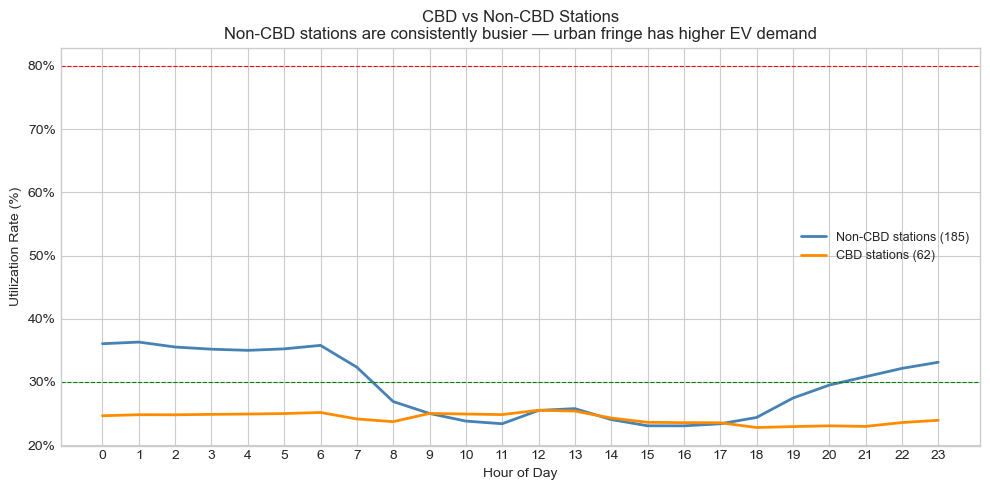

In [29]:
# ============================================================
# CHART 6: CBD vs Non-CBD stations
# Location affects demand pattern — CBD stations behave differently
# ============================================================

cbd_hourly = master.groupby(['CBD', 'hour'])['utilization_rate'].mean().unstack()
# CBD ka matlab hota hai Central Business District
fig, ax = plt.subplots(figsize=(10, 5))


# Jab aap apna AI Agent banayenge, toh kya aap har jagah ek hi rate lagayenge? Nahi! Yeh chart judges ko batata hai ki:
# "Dekhiye, main market (CBD) aur residential areas (Non-CBD) mein bheed ka tareeqa bilkul alag hai.
# Data saaf dikha raha hai ki Non-CBD areas mein log zyada charging karte hain (shayad raat bhar gaadi park karke). 
# Isliye hamara AI siraf time dekh kar nahi, balki Station ki Location dekh kar bhi alag-alag rate decide karega."
ax.plot(range(24), cbd_hourly.loc[0] * 100,
        color='steelblue', linewidth=2, label='Non-CBD stations (185)')

ax.plot(range(24), cbd_hourly.loc[1] * 100,
        color='darkorange', linewidth=2, label='CBD stations (62)')

ax.axhline(80, color='red',   linestyle='--', linewidth=0.8)
ax.axhline(30, color='green', linestyle='--', linewidth=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Utilization Rate (%)')
ax.set_title('CBD vs Non-CBD Stations\nNon-CBD stations are consistently busier — urban fringe has higher EV demand')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart6_cbd_vs_noncbd.png', dpi=150, bbox_inches='tight')
plt.show()

## Agla code college campus ka hai

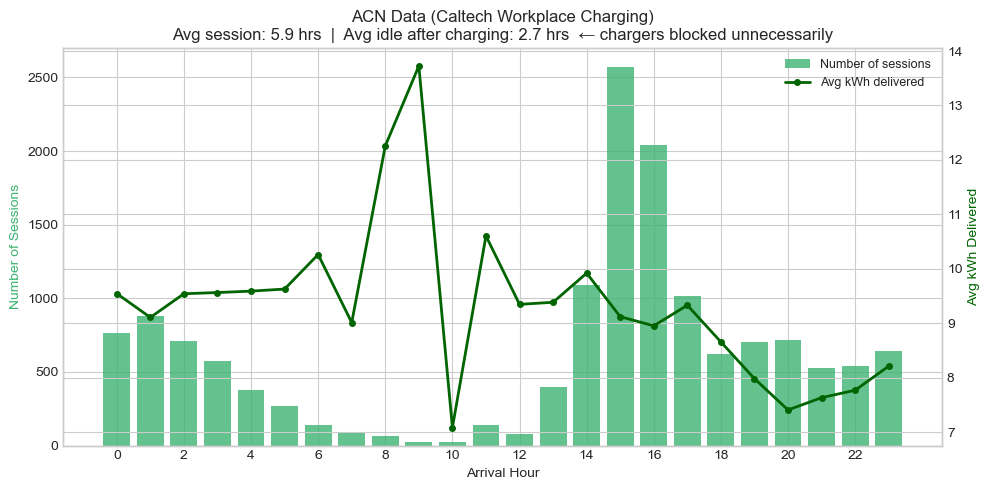

Avg session duration:           5.92 hours
Avg idle time after charging:   2.69 hours
Idle % of total session time:   45.4%


In [31]:
# ============================================================
# CHART 7: ACN Data — Caltech workplace charging
# Shows session volume + avg kWh by arrival hour
# Key finding: people arrive 8-10am and leave cars plugged in for ~6 hours
# ============================================================


# Agar aap kisi ko bolenge ki "Log gaadi charge hone ke baad bhi hatate nahi hain aur charger block karte hain", toh samne wala poochega: "Proof kya hai?"
# Public EV data mein aksar 'Idle Time' (khali khade rehne ka waqt) record nahi hota. Isliye aapne Caltech University (ek workplace/office) ka asli ACN data uthaya.
# Yeh chart aur iske calculations sabse bada proof hain ki log subah 8-9 baje office aate hain, gaadi charge pe lagate hain, aur shaam tak (6-8 ghante) gaadi wahi chhod dete hain, 
# jabki charge hone mein sirf 2-3 ghante lagte hain. Is chart se aap apne AI Agent ke "Idle Penalty" (Khali khade rehne par fine lagana) wale feature ko 100% justify kar payenge!

acn_df = pd.read_excel('/Users/shabadpreetsingh/Downloads/Socbiz Summer Project/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx')

acn_df['connectionTime']   = pd.to_datetime(acn_df['connectionTime'],   utc=True, errors='coerce')
acn_df['disconnectTime']   = pd.to_datetime(acn_df['disconnectTime'],   utc=True, errors='coerce')#utc matlab time zone theek krta hai
acn_df['doneChargingTime'] = pd.to_datetime(acn_df['doneChargingTime'], utc=True, errors='coerce')#coerce matlab agar chotta sa error aaye toh code burst na ho

acn_df['arrival_hour']  = acn_df['connectionTime'].dt.hour
acn_df['session_hours'] = (acn_df['disconnectTime']   - acn_df['connectionTime']).dt.total_seconds() / 3600
acn_df['idle_hours']    = (acn_df['disconnectTime']   - acn_df['doneChargingTime']).dt.total_seconds() / 3600
acn_df['idle_hours']    = acn_df['idle_hours'].clip(lower=0)

acn_hourly = acn_df.groupby('arrival_hour')['kWhDelivered'].agg(['count', 'mean']).reset_index()
#Matlab: Har ghante ke hisaab se groups banao. Phir check karo ki kitni gaadiyan aayi (count), aur average kitni bijli khayi (mean).
fig, ax = plt.subplots(figsize=(10, 5))
ax_twin = ax.twinx()

ax.bar(acn_hourly['arrival_hour'], acn_hourly['count'],
       color='mediumseagreen', alpha=0.8, label='Number of sessions')

ax_twin.plot(acn_hourly['arrival_hour'], acn_hourly['mean'],
             color='darkgreen', linewidth=2, marker='o', markersize=4,
             label='Avg kWh delivered')

ax.set_xlabel('Arrival Hour')
ax.set_ylabel('Number of Sessions', color='mediumseagreen')
ax_twin.set_ylabel('Avg kWh Delivered', color='darkgreen')
ax.set_title(f'ACN Data (Caltech Workplace Charging)\n'
             f'Avg session: {acn_df["session_hours"].mean():.1f} hrs  |  '
             f'Avg idle after charging: {acn_df["idle_hours"].mean():.1f} hrs  ← chargers blocked unnecessarily')
ax.set_xticks(range(0, 24, 2))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig('chart7_acn_arrivals.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key numbers so they appear below the chart in your notebook
print(f"Avg session duration:           {acn_df['session_hours'].mean():.2f} hours")
print(f"Avg idle time after charging:   {acn_df['idle_hours'].mean():.2f} hours")
print(f"Idle % of total session time:   {acn_df['idle_hours'].mean() / acn_df['session_hours'].mean() * 100:.1f}%")



# Aapne ekdum sahi cheez try ki! Code ko tod kar dekhna hi seekhne ka sabse best tareeqa hai. Jab aapne usko hataya hoga, toh screen par ek red color ka bada sa error aaya hoga (shayad `KeyError: 'arrival_hour'`).

# Chaliye is raaz ko kholte hain ki `.reset_index()` lagana itna zaroori kyun tha aur iske bina code kyun ro pada!

# Isko **Excel ke "Row Numbers"** ke example se samajhte hain:

# ### **Problem kya hui jab aapne ise hataya? (Without reset_index)**

# Jab hum `.groupby('arrival_hour')` karte hain, toh Pandas `arrival_hour` ko utha kar table ke andar se bahar nikal deta hai, aur usko **"Index" (Row Number)** bana deta hai.

# Excel mein jo left side par fixed numbers hote hain na (1, 2, 3...), Pandas `arrival_hour` ko wahi fixed label bana deta hai.

# Table kuch aisi dikhti hai (dhyan se dekhiye, arrival_hour ab column nahi raha, border ban gaya hai):

# | (Row Labels / Index) | count | mean |
# | --- | --- | --- |
# | **8** | 145 | 12.5 |
# | **9** | 210 | 14.2 |

# **Code yahan kyu crash hua?**
# Aage chalkar graph banane ke liye aapne code mein likha:
# `ax.bar(acn_hourly['arrival_hour'], ...)`

# Is line ne Pandas se kaha: *"Bhai mujhe 'arrival_hour' naam ka column de do, mujhe X-axis par graph draw karna hai."*
# Pandas ne check kiya aur bola: *"Mere paas toh 'arrival_hour' naam ka koi column hai hi nahi! Wo toh ab mera Row Number (Index) ban chuka hai."* Aur bas, Python confused ho gaya aur code crash ho gaya.

# ---

# ### **`.reset_index()` ne aakar kya jaadu kiya?**

# `.reset_index()` ka seedha sa matlab hai: **"Bhai sab kuch wapas normal kar do."**

# Yeh command kya karti hai:

# 1. Yeh un `8, 9, 10` ko Index (Row number) ki post se hata kar, wapas andar kheench leti hai aur ek **normal Column** bana deti hai.
# 2. Aur left side par naye, normal Row numbers (0, 1, 2, 3...) laga deti hai.

# Ab table ekdum normal Excel sheet jaisi dikhti hai:

# | (Index) | arrival_hour | count | mean |
# | --- | --- | --- | --- |
# | **0** | 8 | 145 | 12.5 |
# | **1** | 9 | 210 | 14.2 |

# **Code kyu chal gaya?**
# Ab jab graph wale code ne maanga ki *"Mujhe 'arrival_hour' ka column do"*, toh Pandas ne turant nikal kar de diya kyunki ab wo ek proper column ban chuka tha!

# **Short mein:** `.groupby` table ka design bigad deta hai aur headings ko border bana deta hai. `.reset_index()` us bigde hue design ko wapas theek karke usko ek normal table bana deta hai, taaki Matplotlib (graph banane wala tool) usko asani se padh sake.

# Ab samajh aaya ki wo error kyun aa raha tha?

1. Asli Problem Kya Hai? (Average vs. Individual)
Surge pricing kabhi bhi poore shehar par ek saath nahi lagti. Wo sirf us ek khaas station par lagti hai jo 80% full ho chuka hai.
Lekin Heatmap kya dikha raha hai? Wo poore 247 stations ka Total Average dikha raha hai.
Jab poore shehar ka average 50% hota hai, toh iska matlab yeh hota hai ki shehar ke kuch main stations (jaise P90 wale) sach mein 80-90% par chal रहे hain (surge zone mein), aur baaki aam stations 20-30% par khali hain.
2. Toh Ise Theek Kaise Karein? (The Honest Fix)
Hum color scale (vmax) ko zaroor change karenge taaki graph pheeka (pale) na lage, lekin hum judges se jhooth nahi bolenge. Hum bas apne Heatmap ke Title ko theek kar denge.
Pehle hamara title keh raha tha: "Red = congested -> surge". Yeh technically galat tha.
Humein isko badal kar likhna chahiye: "Red = Peak Network Traffic"